# Enclave Benchmark — Event Timeline Analysis

Loads `logs.csv`, extracts per-ID event timestamps (`published`, `assigned`, `started`, `cleanup`), computes time deltas between each phase, and visualises them as stacked horizontal bars and distribution plots.

In [15]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

plt.rcParams.update({'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3})

DATA_PATH = Path('..') / 'logs.csv'
assert DATA_PATH.exists(), f'logs.csv not found at {DATA_PATH.absolute()}'

raw = pd.read_csv(DATA_PATH)

def parse_fields(x):
    if pd.isna(x) or x == '':
        return {}
    try:
        return json.loads(x)
    except Exception:
        return {}

raw['fields_parsed'] = raw['fields'].apply(parse_fields)

# Keep only benchmark event rows that have an id and event type
events = raw[raw['fields_parsed'].apply(lambda d: 'event' in d and 'id' in d)].copy()
events['event']     = events['fields_parsed'].apply(lambda d: d['event'])
events['id']        = events['fields_parsed'].apply(lambda d: d['id'])
events['evt_ts']    = events['fields_parsed'].apply(lambda d: pd.to_datetime(d['timestamp']))

print(f'Total event rows : {len(events):,}')
print()
print('Event counts:')
print(events['event'].value_counts().to_string())

Total event rows : 122

Event counts:
event
started      61
published    60
pulled        1


In [16]:
# --- Pivot: one row per ID, columns = event timestamps ---
PHASES = ['published', 'assigned', 'started', 'cleanup']

pivot = (
    events[events['event'].isin(PHASES)]
    .sort_values('evt_ts')
    .drop_duplicates(subset=['id', 'event'], keep='first')
    .pivot(index='id', columns='event', values='evt_ts')
)

# Only keep columns that actually exist in the data
present = [p for p in PHASES if p in pivot.columns]
pivot = pivot[present]
print('Available phases:', present)
print(f'IDs with at least one event: {len(pivot):,}')
print()

# --- Compute deltas (ms) between consecutive and key phase pairs ---
def delta_ms(df, a, b):
    """Return (b - a) in ms for rows where both columns exist."""
    if a in df.columns and b in df.columns:
        return (df[b] - df[a]).dt.total_seconds() * 1000
    return pd.Series(dtype=float, name=f'{a}→{b}')

timings = pd.DataFrame(index=pivot.index)
timings['published→assigned'] = delta_ms(pivot, 'published', 'assigned')
timings['assigned→started']   = delta_ms(pivot, 'assigned',  'started')
timings['assigned→cleanup']   = delta_ms(pivot, 'assigned',  'cleanup')
timings['published→started']  = delta_ms(pivot, 'published', 'started')
timings['published→cleanup']  = delta_ms(pivot, 'published', 'cleanup')

# Attach publish time for ordering
timings['published_at'] = pivot.get('published')

# Drop rows that have no usable deltas at all
timings = timings.dropna(how='all', subset=[c for c in timings.columns if '→' in c])

print('Timing summary (ms):')
delta_cols = [c for c in timings.columns if '→' in c]
summary = timings[delta_cols].describe(percentiles=[.5, .9, .95, .99]).T
summary.columns = summary.columns.str.replace('%', 'th')
print(summary[['count','mean','min','50th','90th','95th','99th','max']].to_string(float_format=lambda x: f'{x:,.1f}'))

Available phases: ['published', 'started']
IDs with at least one event: 61

Timing summary (ms):
                    count    mean   min    50th    90th    95th    99th     max
published→assigned    0.0     NaN   NaN     NaN     NaN     NaN     NaN     NaN
assigned→started      0.0     NaN   NaN     NaN     NaN     NaN     NaN     NaN
assigned→cleanup      0.0     NaN   NaN     NaN     NaN     NaN     NaN     NaN
published→started    60.0 1,011.6 431.0 1,095.6 1,324.0 1,365.2 1,452.4 1,485.4
published→cleanup     0.0     NaN   NaN     NaN     NaN     NaN     NaN     NaN


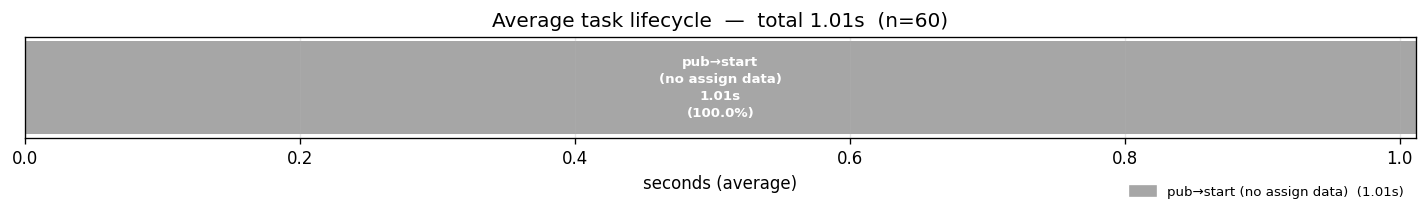

In [17]:
# --- Single stacked horizontal bar: average duration of each consecutive phase ---
# Segments represent the average time spent in each phase, stacked left to right.
# Only consecutive phases are shown (not overlapping spans like pub→start).

SEGMENTS = [
    ('published→assigned', '#5b9bd5', 'queue wait\n(pub→assign)'),
    ('assigned→started',   '#ed7d31', 'boot\n(assign→start)'),
    ('assigned→cleanup',   '#70ad47', 'run\n(start→cleanup)'),  # assign→cleanup minus assign→started = run
]

# For the run segment we want started→cleanup, not assigned→cleanup.
# Derive it if both assigned→started and assigned→cleanup are present.
if 'assigned→started' in timings.columns and 'assigned→cleanup' in timings.columns:
    timings['started→cleanup'] = timings['assigned→cleanup'] - timings['assigned→started']
    SEGMENTS[-1] = ('started→cleanup', '#70ad47', 'run\n(start→cleanup)')
elif 'published→started' in timings.columns and 'published→cleanup' in timings.columns:
    timings['started→cleanup'] = timings['published→cleanup'] - timings['published→started']
    SEGMENTS[-1] = ('started→cleanup', '#70ad47', 'run\n(start→cleanup)')

# Fall back: if no assign data, use published→started as the only segment
has_assign = 'published→assigned' in timings.columns and timings['published→assigned'].notna().sum() > 0
if not has_assign:
    SEGMENTS = [('published→started', '#a6a6a6', 'pub→start\n(no assign data)')]

avgs = {}
for col, color, label in SEGMENTS:
    if col in timings.columns:
        v = timings[col].dropna()
        if len(v) > 0:
            avgs[col] = (v.mean() / 1000, color, label)  # seconds

total = sum(v for v, _, _ in avgs.values())

fig, ax = plt.subplots(figsize=(12, 2.2))
left = 0
for col, (dur, color, label) in avgs.items():
    frac = dur / total
    ax.barh(0, dur, left=left, height=0.5, color=color, align='center')
    if frac > 0.04:   # only label if segment is wide enough
        ax.text(left + dur / 2, 0, f'{label}\n{dur:.2f}s\n({frac*100:.1f}%)',
                ha='center', va='center', fontsize=8, color='white', fontweight='bold',
                linespacing=1.4)
    left += dur

ax.set_xlim(0, total)
ax.set_xlabel('seconds (average)')
ax.set_yticks([])
ax.set_title(f'Average task lifecycle  —  total {total:.2f}s  (n={timings.dropna(subset=list(avgs.keys()), how="all").shape[0]})')

legend_handles = [mpatches.Patch(color=c, label=f'{lbl.replace(chr(10), " ")}  ({avgs[col][0]:.2f}s)')
                  for col, (_, c, lbl) in avgs.items()]
ax.legend(handles=legend_handles, loc='upper right', bbox_to_anchor=(1, -0.35),
          ncol=len(avgs), fontsize=8, frameon=False)

plt.tight_layout()
plt.show()

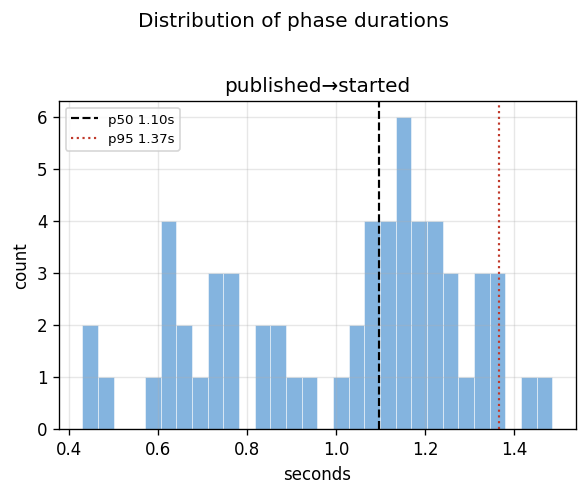

In [18]:
# --- Distribution of each delta: overlapping histograms ---
delta_cols = [c for c in timings.columns if '→' in c]
available  = [c for c in delta_cols if timings[c].notna().sum() > 1]

COLORS = ['#5b9bd5', '#ed7d31', '#70ad47', '#a550a5', '#c00000']

fig, axes = plt.subplots(1, len(available), figsize=(5 * len(available), 4), squeeze=False)

for ax, col, color in zip(axes[0], available, COLORS):
    vals = timings[col].dropna() / 1000   # → seconds
    ax.hist(vals, bins=30, color=color, alpha=0.75, edgecolor='white', linewidth=0.4)
    med = np.median(vals)
    p95 = np.percentile(vals, 95)
    ax.axvline(med, color='black',   linestyle='--', linewidth=1.3, label=f'p50 {med:.2f}s')
    ax.axvline(p95, color='#c0392b', linestyle=':',  linewidth=1.3, label=f'p95 {p95:.2f}s')
    ax.set_xlabel('seconds')
    ax.set_ylabel('count')
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.suptitle('Distribution of phase durations', y=1.02)
plt.tight_layout()
plt.show()

/var/folders/9m/sj0s8n3n4w3_x6ygrt7_k4080000gn/T/ipykernel_10418/2293699378.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


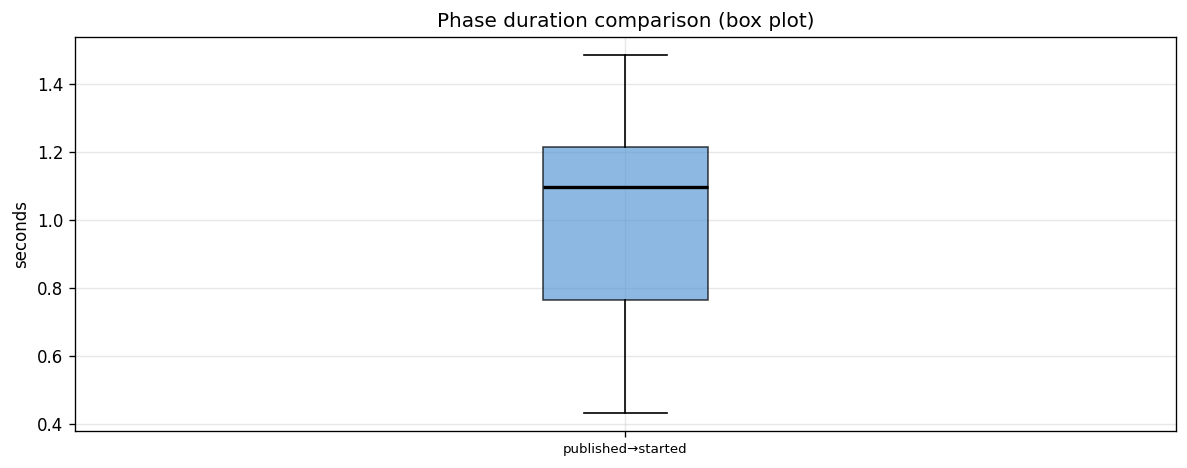

In [19]:
# --- Box plots: all deltas side-by-side for quick comparison ---
available_data = {c: timings[c].dropna() / 1000 for c in delta_cols if timings[c].notna().sum() > 1}

fig, ax = plt.subplots(figsize=(10, 4))
bp = ax.boxplot(
    list(available_data.values()),
    labels=list(available_data.keys()),
    patch_artist=True,
    flierprops=dict(marker='.', markersize=3, alpha=0.4),
    medianprops=dict(color='black', linewidth=2),
)
colors = ['#5b9bd5', '#ed7d31', '#70ad47', '#a550a5', '#c00000']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.set_ylabel('seconds')
ax.set_title('Phase duration comparison (box plot)')
ax.tick_params(axis='x', labelsize=8)
plt.tight_layout()
plt.show()

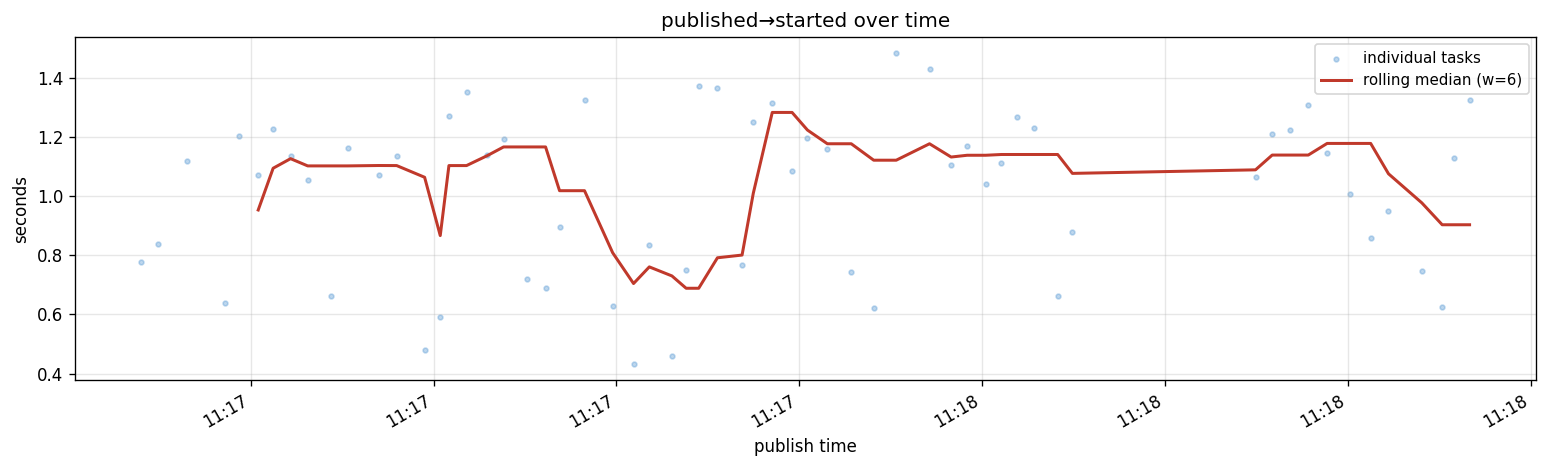

In [20]:
# --- pub→start over time: rolling median to spot trends ---
ts_col = 'published→started'
if ts_col in timings.columns and timings[ts_col].notna().sum() > 5:
    ts_data = (
        timings[['published_at', ts_col]]
        .dropna()
        .sort_values('published_at')
    )
    window = max(5, len(ts_data) // 10)
    roll_med = ts_data[ts_col].rolling(window).median() / 1000

    fig, ax = plt.subplots(figsize=(13, 4))
    ax.scatter(ts_data['published_at'], ts_data[ts_col] / 1000,
               s=8, alpha=0.4, color='#5b9bd5', label='individual tasks')
    ax.plot(ts_data['published_at'], roll_med,
            color='#c0392b', linewidth=1.8, label=f'rolling median (w={window})')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    fig.autofmt_xdate()
    ax.set_xlabel('publish time')
    ax.set_ylabel('seconds')
    ax.set_title('published→started over time')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()
else:
    print(f'Not enough data for {ts_col} trend plot.')

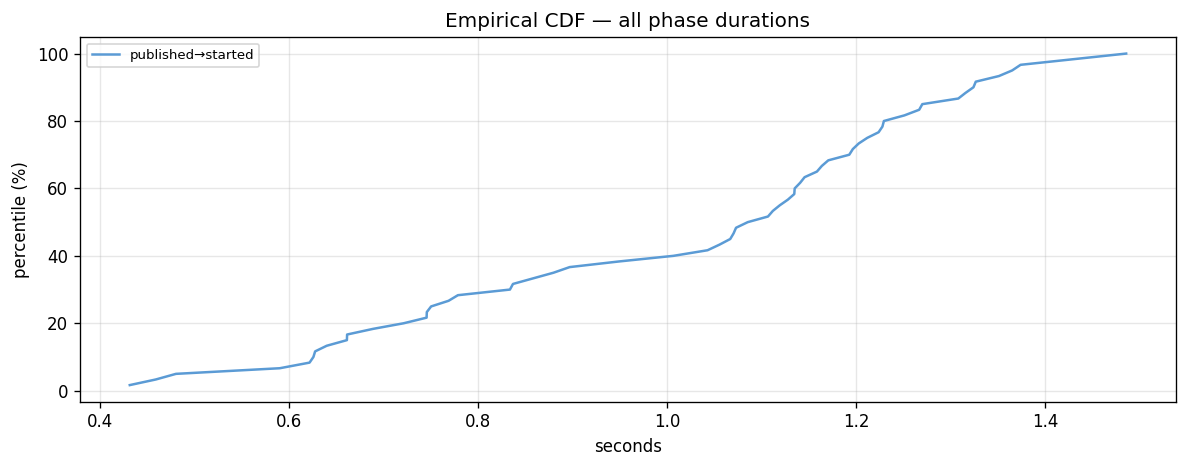

In [21]:
# --- Empirical CDF for all available deltas ---
fig, ax = plt.subplots(figsize=(10, 4))
colors = ['#5b9bd5', '#ed7d31', '#70ad47', '#a550a5', '#c00000']

for col, color in zip(available_data.keys(), colors):
    vals = np.sort(available_data[col].values)
    cdf  = np.arange(1, len(vals) + 1) / len(vals)
    ax.plot(vals, cdf * 100, color=color, linewidth=1.5, label=col)

ax.set_xlabel('seconds')
ax.set_ylabel('percentile (%)')
ax.set_title('Empirical CDF — all phase durations')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()